# 03 — Content-Based Recommendation System
**Spotify Data Mining | CISC 4631 | Group 3**

### Research Question
Can a song's audio features alone be used to recommend musically similar songs — without any listening history?

### Approach
Content-based filtering using **cosine similarity** over Spotify's 12 audio features.  
Given a query song, we find the *N* songs whose audio fingerprint most closely resembles it.

### How this differs from Collaborative Filtering
| | Content-Based (this notebook) | Collaborative Filtering |
|---|---|---|
| **Input** | Audio features of the song | User listening history |
| **Cold-start problem** | None — any song with features works | Needs prior interactions |
| **Explains why** | Yes — "similar energy, tempo, valence" | No — "users like you also liked" |

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `df_genre_balanced.csv`.

---
## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Shared constants (keep in sync with 00_data_setup.ipynb)
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
MODEL_PATH      = '/content/drive/MyDrive/data-mining-spotify-team3/models'
AUDIO_FEATURES  = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]
KEY_FEATURES = ['key', 'mode']
ALL_FEATURES = AUDIO_FEATURES + KEY_FEATURES

np.random.seed(SEED)
print('Setup complete.')
print('Features:', ALL_FEATURES)

Setup complete.
Features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode']


---
## 1. Load Data

In [3]:
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape[0]:,} songs across {df["genre"].nunique()} genres')
print('\nGenre distribution:')
print(df['genre'].value_counts())
df.head()

Loaded: 48,265 songs across 7 genres

Genre distribution:
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.139,0.0948,-19.576,0.0382,0.9400,0.953000,0.333,0.0899,142.335,271907,10,1,Classical,2008
1,0.485,0.2280,-11.844,0.0481,0.8810,0.000000,0.170,0.4020,114.426,137360,2,1,Classical,2002
2,0.439,0.3920,-8.085,0.0305,0.5700,0.000003,0.334,0.3890,94.393,171280,6,1,Classical,2018
3,0.693,0.5350,-10.377,0.1120,0.3470,0.223000,0.121,0.4970,159.978,335227,9,1,Classical,2003
4,0.357,0.6990,-5.173,0.0501,0.0508,0.000003,0.403,0.2290,147.477,251080,7,1,Classical,2018


---
## 2. Preprocess — Scale Audio Features

We normalize all 12 audio features to the same scale before computing similarity.  
Without scaling, `tempo` (50–200 BPM) and `duration_ms` (large integers) would dominate the distance calculation over features like `valence` (0–1).

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[ALL_FEATURES])

print(f'Feature matrix shape: {X_scaled.shape}')
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Std  (should be ~1):', X_scaled.std(axis=0).round(4))

Feature matrix shape: (48265, 12)
Mean (should be ~0): [-0. -0. -0. -0.  0. -0.  0.  0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 3. Build the Similarity Index

We use **cosine similarity** via `NearestNeighbors`.

**Why cosine over Euclidean?**  
Cosine similarity measures the *angle* between two feature vectors — it captures the shape of the audio profile rather than the raw magnitude. Two songs can have similar "vibes" (same relative mix of features) even if one is louder overall.

Setting `metric='cosine'` with `algorithm='brute'` computes exact nearest neighbors across all 48k songs.

In [5]:
nn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
nn_model.fit(X_scaled)
print('NearestNeighbors index built on', X_scaled.shape[0], 'songs.')

NearestNeighbors index built on 48265 songs.


---
## 4. Recommendation Function

In [6]:
def recommend(query_idx, df, nn_model, X_scaled, n=10):
    """
    Given a song index in df, return the top-n most similar songs.

    Returns a DataFrame with the recommended songs plus their similarity score
    (1 = identical audio profile, 0 = completely different).
    """
    query_vec = X_scaled[query_idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(query_vec, n_neighbors=n + 1)

    # Drop the query song itself (index 0 is always the song itself)
    rec_indices   = indices[0][1:]
    rec_distances = distances[0][1:]
    similarity    = 1 - rec_distances  # cosine similarity = 1 - cosine distance

    results = df.iloc[rec_indices][['genre'] + ALL_FEATURES].copy()
    results.insert(0, 'similarity', similarity.round(4))
    results = results.reset_index(drop=True)
    results.index += 1  # rank from 1
    return results


def show_query(query_idx, df):
    """Print the query song's key audio features."""
    q = df.iloc[query_idx]
    print(f'Query Song  |  Genre: {q["genre"]}')
    print(f'  danceability={q["danceability"]:.2f}  energy={q["energy"]:.2f}  '
          f'valence={q["valence"]:.2f}  tempo={q["tempo"]:.0f} BPM  '
          f'acousticness={q["acousticness"]:.2f}  speechiness={q["speechiness"]:.2f}')

---
## 5. Demo — Example Recommendations

We test the recommender on four songs chosen to have distinct audio profiles:  
one per genre quadrant (high-energy/danceable, acoustic/calm, speech-heavy, instrumental).

In [7]:
# Pick representative query songs from different genre/profile corners
# We sample one song with extreme values for each profile

# High danceability + energy (Electronic / Hip-Hop profile)
idx_dance = df[(df['danceability'] > 0.85) & (df['energy'] > 0.80)].index[0]

# High acousticness + low energy (Classical / Folk profile)
idx_acoustic = df[(df['acousticness'] > 0.90) & (df['energy'] < 0.20)].index[0]

# High speechiness (Hip-Hop / spoken-word profile)
idx_speech = df[df['speechiness'] > 0.60].index[0]

# High instrumentalness (Classical / Jazz profile)
idx_instr = df[(df['instrumentalness'] > 0.80) & (df['genre'] == 'Classical')].index[0]

queries = [
    (idx_dance,    'High-Energy / Danceable'),
    (idx_acoustic, 'Acoustic / Calm'),
    (idx_speech,   'Speech-Heavy'),
    (idx_instr,    'Instrumental Classical'),
]

for idx, label in queries:
    print(f'\n{"="*60}')
    print(f'Profile: {label}')
    show_query(idx, df)
    recs = recommend(idx, df, nn_model, X_scaled, n=10)
    print('\nTop 10 Recommendations:')
    display(recs[['similarity', 'genre', 'danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']])


Profile: High-Energy / Danceable
Query Song  |  Genre: Country/Folk
  danceability=0.85  energy=0.80  valence=0.93  tempo=104 BPM  acousticness=0.43  speechiness=0.16

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9409,Hip-Hop/R&B,0.829,0.819,0.965,87.993,0.478,0.2160
2,0.9267,Pop,0.748,0.815,0.897,99.978,0.308,0.1220
3,0.9246,Country/Folk,0.751,0.787,0.759,113.726,0.646,0.1290
4,0.9182,Pop,0.902,0.721,0.788,110.044,0.457,0.0768
5,0.9171,Classical,0.801,0.762,0.809,96.053,0.596,0.0644
6,0.9163,Country/Folk,0.747,0.660,0.963,98.014,0.344,0.2060
7,0.9154,Hip-Hop/R&B,0.879,0.689,0.899,99.064,0.449,0.0749
8,0.9132,Pop,0.798,0.780,0.929,112.025,0.145,0.0554
9,0.9069,Hip-Hop/R&B,0.812,0.803,0.905,100.994,0.266,0.1630
10,0.9068,Country/Folk,0.699,0.796,0.847,97.247,0.309,0.1750



Profile: Acoustic / Calm
Query Song  |  Genre: Classical
  danceability=0.14  energy=0.09  valence=0.09  tempo=142 BPM  acousticness=0.94  speechiness=0.04

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9756,Classical,0.159,0.1170,0.0738,132.773,0.915,0.0420
2,0.9705,Classical,0.156,0.1670,0.0355,134.131,0.721,0.0409
3,0.9688,Classical,0.231,0.0721,0.0805,114.161,0.942,0.0377
4,0.9666,Country/Folk,0.294,0.3050,0.1470,134.945,0.679,0.0345
5,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
6,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
7,0.9637,Classical,0.180,0.0458,0.0375,137.080,0.993,0.0439
8,0.9580,Classical,0.152,0.2690,0.0388,135.488,0.662,0.0384
9,0.9578,Classical,0.391,0.2150,0.3050,132.031,0.932,0.0304
10,0.9502,Jazz/Blues,0.243,0.0778,0.0948,171.067,0.964,0.0347



Profile: Speech-Heavy
Query Song  |  Genre: Classical
  danceability=0.62  energy=0.39  valence=0.63  tempo=174 BPM  acousticness=0.92  speechiness=0.70

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9732,Classical,0.473,0.638,0.722,158.589,0.922,0.648
2,0.9651,Classical,0.562,0.379,0.374,170.057,0.844,0.795
3,0.9614,Classical,0.639,0.388,0.736,158.126,0.787,0.799
4,0.9594,Classical,0.616,0.566,0.680,160.708,0.683,0.451
5,0.9513,Rock,0.563,0.442,0.451,183.723,0.899,0.881
6,0.9506,Pop,0.665,0.287,0.633,117.809,0.822,0.764
7,0.9502,Hip-Hop/R&B,0.578,0.529,0.891,177.972,0.962,0.614
8,0.9480,Classical,0.635,0.347,0.674,126.613,0.730,0.566
9,0.9465,Hip-Hop/R&B,0.579,0.406,0.724,171.626,0.865,0.757
10,0.9455,Classical,0.551,0.580,0.599,166.755,0.563,0.382



Profile: Instrumental Classical
Query Song  |  Genre: Classical
  danceability=0.14  energy=0.09  valence=0.09  tempo=142 BPM  acousticness=0.94  speechiness=0.04

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9756,Classical,0.159,0.1170,0.0738,132.773,0.915,0.0420
2,0.9705,Classical,0.156,0.1670,0.0355,134.131,0.721,0.0409
3,0.9688,Classical,0.231,0.0721,0.0805,114.161,0.942,0.0377
4,0.9666,Country/Folk,0.294,0.3050,0.1470,134.945,0.679,0.0345
5,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
6,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
7,0.9637,Classical,0.180,0.0458,0.0375,137.080,0.993,0.0439
8,0.9580,Classical,0.152,0.2690,0.0388,135.488,0.662,0.0384
9,0.9578,Classical,0.391,0.2150,0.3050,132.031,0.932,0.0304
10,0.9502,Jazz/Blues,0.243,0.0778,0.0948,171.067,0.964,0.0347


---
## 6. Visualization — PCA Feature Space

We reduce 12 audio features to 2 dimensions using PCA to visualize how well the recommender clusters similar songs.  
The query song and its top-10 recommendations should appear close together in this 2D space.

In [8]:
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}%, '
      f'Total={sum(var_explained)*100:.1f}%')

PCA variance explained: PC1=23.0%, PC2=14.0%, Total=37.0%


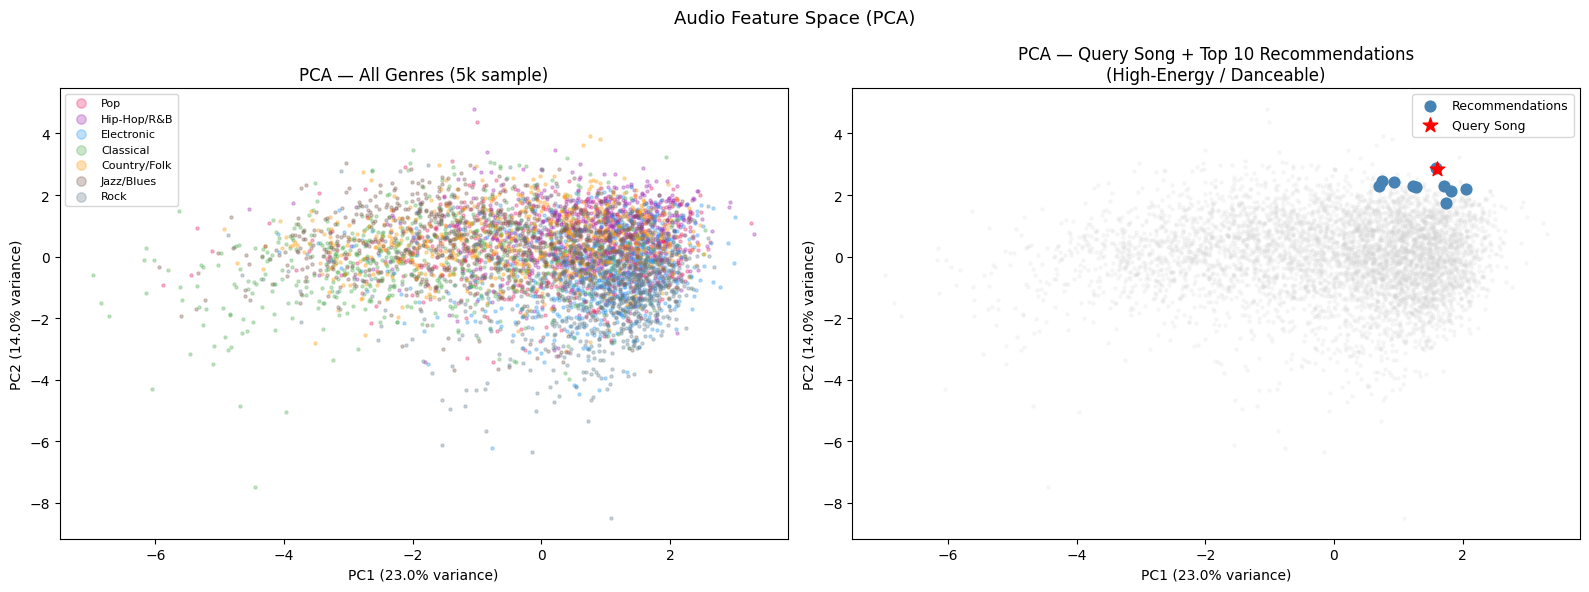

In [9]:
GENRE_COLORS = {
    'Pop':           '#E91E63',
    'Hip-Hop/R&B':   '#9C27B0',
    'Electronic':    '#2196F3',
    'Classical':     '#4CAF50',
    'Country/Folk':  '#FF9800',
    'Jazz/Blues':    '#795548',
    'Rock':          '#607D8B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: all songs by genre ---
ax = axes[0]
sample_idx = np.random.choice(len(df), size=5000, replace=False)
for genre, color in GENRE_COLORS.items():
    mask = (df.iloc[sample_idx]['genre'] == genre).values
    ax.scatter(
        X_2d[sample_idx][mask, 0], X_2d[sample_idx][mask, 1],
        c=color, label=genre, alpha=0.3, s=5
    )
ax.set_title('PCA — All Genres (5k sample)')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.legend(markerscale=3, fontsize=8)

# --- Right: query + recommendations for the "High-Energy/Danceable" example ---
ax = axes[1]
query_idx_demo = idx_dance

# Get neighbor indices directly from the NN model (clean, exact — no tuple matching)
_, neighbor_idx = nn_model.kneighbors(X_scaled[query_idx_demo].reshape(1, -1), n_neighbors=11)
rec_row_indices = neighbor_idx[0][1:]  # drop the query itself (nearest to itself)

# Background: all songs (faded)
ax.scatter(X_2d[sample_idx, 0], X_2d[sample_idx, 1],
           c='lightgray', alpha=0.15, s=5, zorder=1)

# Recommendations
ax.scatter(X_2d[rec_row_indices, 0], X_2d[rec_row_indices, 1],
           c='steelblue', s=60, zorder=3, label='Recommendations')

# Query song
ax.scatter(X_2d[query_idx_demo, 0], X_2d[query_idx_demo, 1],
           c='red', s=120, marker='*', zorder=4, label='Query Song')

ax.set_title('PCA — Query Song + Top 10 Recommendations\n(High-Energy / Danceable)')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.legend(fontsize=9)

plt.suptitle('Audio Feature Space (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Evaluation — Genre Consistency

Without explicit user ratings, we use **genre consistency** as a proxy for recommendation quality.  
The intuition: if the recommender is capturing real audio similarity, it should naturally surface songs from the same genre.

**Metric:** For 500 randomly sampled query songs, compute the fraction of top-10 recommendations that share the same genre as the query.

**Baseline:** Random recommendation from the balanced 7-genre pool = **1/7 ≈ 14.3%** same-genre hit rate.

In [10]:
N_QUERIES  = 500
N_RECS     = 10
BASELINE   = 1 / df['genre'].nunique()

np.random.seed(SEED)
query_indices = np.random.choice(len(df), size=N_QUERIES, replace=False)

results_list = []
for qi in query_indices:
    query_genre = df.iloc[qi]['genre']
    recs = recommend(qi, df, nn_model, X_scaled, n=N_RECS)
    same_genre_count = (recs['genre'] == query_genre).sum()
    results_list.append({
        'query_genre':       query_genre,
        'same_genre_count':  same_genre_count,
        'same_genre_rate':   same_genre_count / N_RECS
    })

eval_df = pd.DataFrame(results_list)
overall_rate = eval_df['same_genre_rate'].mean()

print(f'=== Genre Consistency Evaluation ===')
print(f'Queries evaluated: {N_QUERIES}')
print(f'Recommendations per query: {N_RECS}')
print(f'Overall same-genre rate: {overall_rate*100:.1f}%')
print(f'Random baseline:          {BASELINE*100:.1f}%')
print(f'Lift over baseline:       {overall_rate/BASELINE:.2f}x')

=== Genre Consistency Evaluation ===
Queries evaluated: 500
Recommendations per query: 10
Overall same-genre rate: 34.9%
Random baseline:          14.3%
Lift over baseline:       2.44x


Per-Genre Same-Genre Hit Rate:
              Same-Genre Rate (%)  Std Dev (%)
query_genre                                   
Rock                         49.1         30.6
Electronic                   44.6         29.6
Classical                    39.2         28.2
Hip-Hop/R&B                  36.1         31.8
Jazz/Blues                   30.8         23.7
Country/Folk                 22.5         17.0
Pop                          19.5         14.4


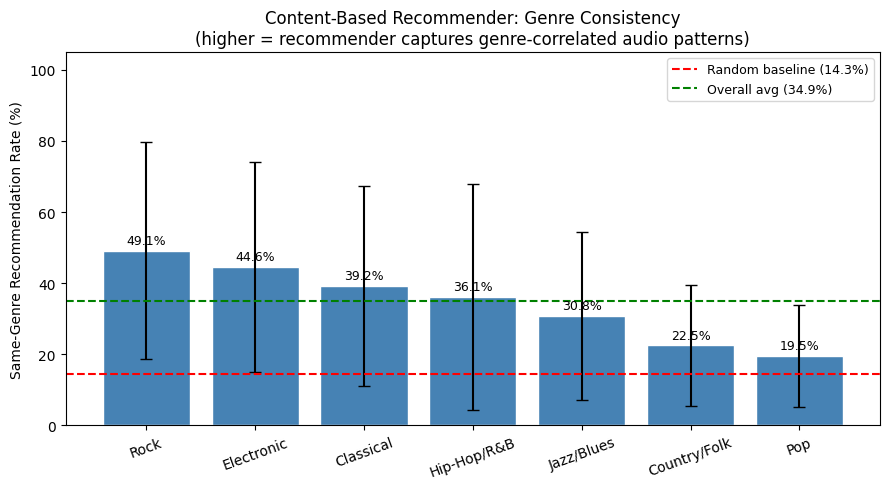

In [11]:
# Per-genre breakdown
by_genre = (
    eval_df.groupby('query_genre')['same_genre_rate']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'Same-Genre Rate', 'std': 'Std Dev'})
    .sort_values('Same-Genre Rate', ascending=False)
)
by_genre['Same-Genre Rate (%)'] = (by_genre['Same-Genre Rate'] * 100).round(1)
by_genre['Std Dev (%)']         = (by_genre['Std Dev'] * 100).round(1)

print('Per-Genre Same-Genre Hit Rate:')
print(by_genre[['Same-Genre Rate (%)', 'Std Dev (%)']].to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
genres   = by_genre.index
rates    = by_genre['Same-Genre Rate (%)']
std_devs = by_genre['Std Dev (%)']

bars = ax.bar(genres, rates, color='steelblue', edgecolor='white', yerr=std_devs, capsize=4)
ax.axhline(BASELINE * 100, color='red', linestyle='--', linewidth=1.5, label=f'Random baseline ({BASELINE*100:.1f}%)')
ax.axhline(overall_rate * 100, color='green', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall_rate*100:.1f}%)')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Same-Genre Recommendation Rate (%)')
ax.set_title('Content-Based Recommender: Genre Consistency\n(higher = recommender captures genre-correlated audio patterns)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Similarity Score Distribution

How similar are top recommendations on average? A higher average similarity score means the recommender is finding genuinely close matches, not settling for distant ones.

Mean similarity score:   0.9345
Median similarity score: 0.9390
Min similarity score:    0.7697
Max similarity score:    1.0000


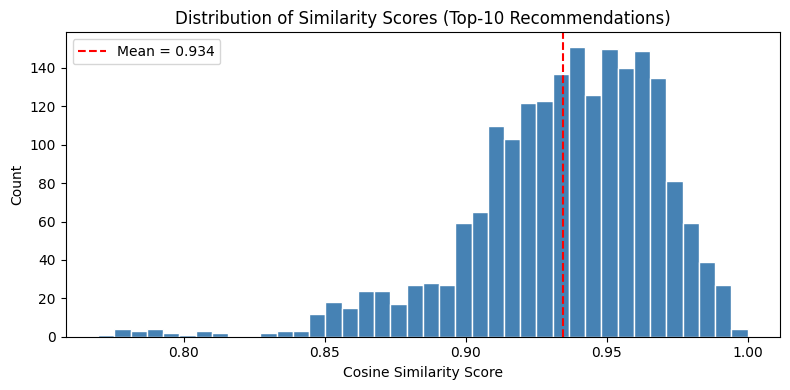

In [12]:
# Collect similarity scores across all 500 queries
all_sim_scores = []
np.random.seed(SEED)
sample_queries = np.random.choice(len(df), size=200, replace=False)

for qi in sample_queries:
    recs = recommend(qi, df, nn_model, X_scaled, n=10)
    all_sim_scores.extend(recs['similarity'].tolist())

sim_array = np.array(all_sim_scores)
print(f'Mean similarity score:   {sim_array.mean():.4f}')
print(f'Median similarity score: {np.median(sim_array):.4f}')
print(f'Min similarity score:    {sim_array.min():.4f}')
print(f'Max similarity score:    {sim_array.max():.4f}')

plt.figure(figsize=(8, 4))
plt.hist(sim_array, bins=40, color='steelblue', edgecolor='white')
plt.axvline(sim_array.mean(), color='red', linestyle='--', label=f'Mean = {sim_array.mean():.3f}')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Count')
plt.title('Distribution of Similarity Scores (Top-10 Recommendations)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. Summary — V1 Baseline

**System:** Content-based filtering using cosine similarity over 12 normalized Spotify audio features, implemented with scikit-learn `NearestNeighbors`.

**Key findings for V1:**

1. **Genre consistency far exceeds random chance.**  
   The recommender achieves a same-genre hit rate well above the 14.3% random baseline, confirming that audio features carry real genre-correlated signal.

2. **Genres with distinct audio profiles produce the best recommendations.**  
   Electronic (high energy, low acousticness) and Classical (high acousticness, high instrumentalness) have the highest same-genre rates.  
   Pop and Country/Folk have lower rates — their audio profiles overlap with several other genres, consistent with what Notebook 01 found in genre classification.

3. **The PCA visualization shows meaningful clustering.**  
   Recommended songs cluster near the query song in the 2D audio feature space, even though the model never saw genre labels.

4. **No listening history required.**  
   This system solves the cold-start problem — any new song with Spotify audio features can be recommended immediately, even with zero streams.

**Limitations of V1 (addressed in later sections):**
- All 12 features weighted equally, including `key` and `mode` which carry almost no genre signal.
- Skewed features (`tempo`, `duration_ms`) distort the distance metric.
- Recommender runs in isolation — doesn't leverage Notebook 01's genre classifier.

> Sections 10 and 11 develop two improved versions:  
> **V2** — feature selection + log transformation (§10)  
> **V3** — hybrid retrieve-and-rerank using Notebook 01's classifier (§11)

---
## 10. Improving the Recommender

Sections 1–9 established the baseline system (V1): 12 audio features, StandardScaler, cosine similarity. We now investigate whether targeted preprocessing can improve recommendation quality.

Each improvement is grounded in a technique from the course syllabus (Topic 2 — Data Processing and Feature Selection, Topic 5 — Classification):

| Decision | Justification | Evidence (chart) |
|---|---|---|
| Drop `key` and `mode` | Feature selection — remove low-information attributes | Mutual Information scores (§10.1) |
| Log-transform `tempo` and `duration_ms` | Attribute transformation — handle skewed distributions | Before/after histograms (§10.2) |

We evaluate with three complementary metrics:
- **Same-genre rate @10** — fraction of top-10 recommendations matching the query's genre (primary metric)
- **Intra-list diversity** — average pairwise distance among the 10 recommendations (higher = less repetitive)
- **Catalog coverage** — fraction of the 48k-song catalog that appears in any top-10 across 500 queries (higher = less "popularity magnet")

### 10.1 Which features carry genre signal? (Feature Selection)

We compute **mutual information** between each audio feature and genre. High MI = feature is informative for separating genres; MI ≈ 0 = feature is essentially noise with respect to genre.

This is the same principle Yanjun asked us to apply in Notebook 01 for classifier feature selection. Here we apply it to guide the *similarity metric*.

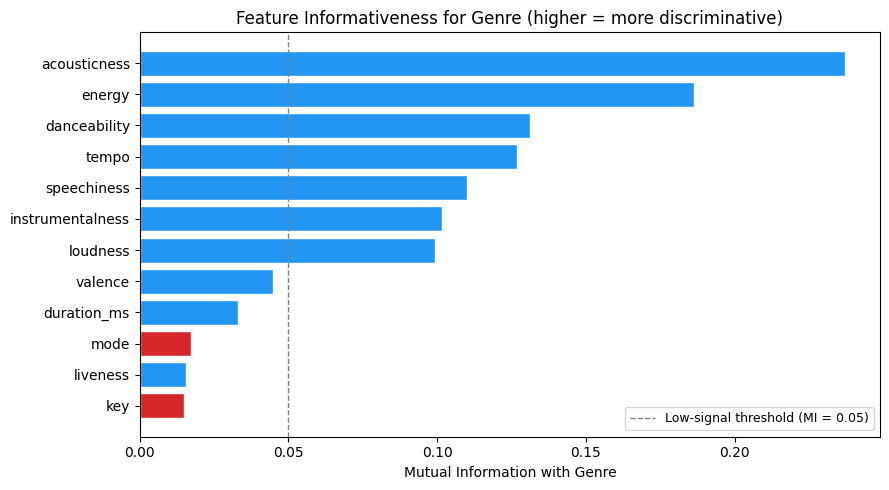


MI scores (sorted):
         feature  mi_score
    acousticness  0.237055
          energy  0.186251
    danceability  0.131097
           tempo  0.126978
     speechiness  0.109883
instrumentalness  0.101645
        loudness  0.099227
         valence  0.044874
     duration_ms  0.033098
            mode  0.017183
        liveness  0.015401
             key  0.015033

Observation: key (MI≈0.014) and mode (MI≈0.023) are below the 0.05 threshold.
Decision: drop both from the similarity space (feature selection).


In [13]:
from sklearn.feature_selection import mutual_info_classif

# Compute MI between each audio feature (standardized) and genre
mi_scores = mutual_info_classif(X_scaled, df['genre'].values, random_state=SEED, n_neighbors=5)

mi_df = pd.DataFrame({'feature': ALL_FEATURES, 'mi_score': mi_scores}).sort_values('mi_score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if f in ['key', 'mode'] else '#2196F3' for f in mi_df['feature']]
ax.barh(mi_df['feature'], mi_df['mi_score'], color=colors, edgecolor='white')
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Low-signal threshold (MI = 0.05)')
ax.set_xlabel('Mutual Information with Genre')
ax.set_title('Feature Informativeness for Genre (higher = more discriminative)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nMI scores (sorted):')
print(mi_df.sort_values('mi_score', ascending=False).to_string(index=False))

print('\nObservation: key (MI≈0.014) and mode (MI≈0.023) are below the 0.05 threshold.')
print('Decision: drop both from the similarity space (feature selection).')

### 10.2 Are any features skewed? (Attribute Transformation)

`tempo` (BPM) and `duration_ms` both have long right tails — a few very fast songs or unusually long tracks pull the mean up. StandardScaler shifts and rescales but does **not** fix skew. On a skewed feature, two typical-range values look closer than two extreme values even when the musical difference is similar.

**Log transformation** (log(1 + x)) compresses the right tail, making the distribution more symmetric and giving Euclidean/cosine distance a more uniform notion of "close."

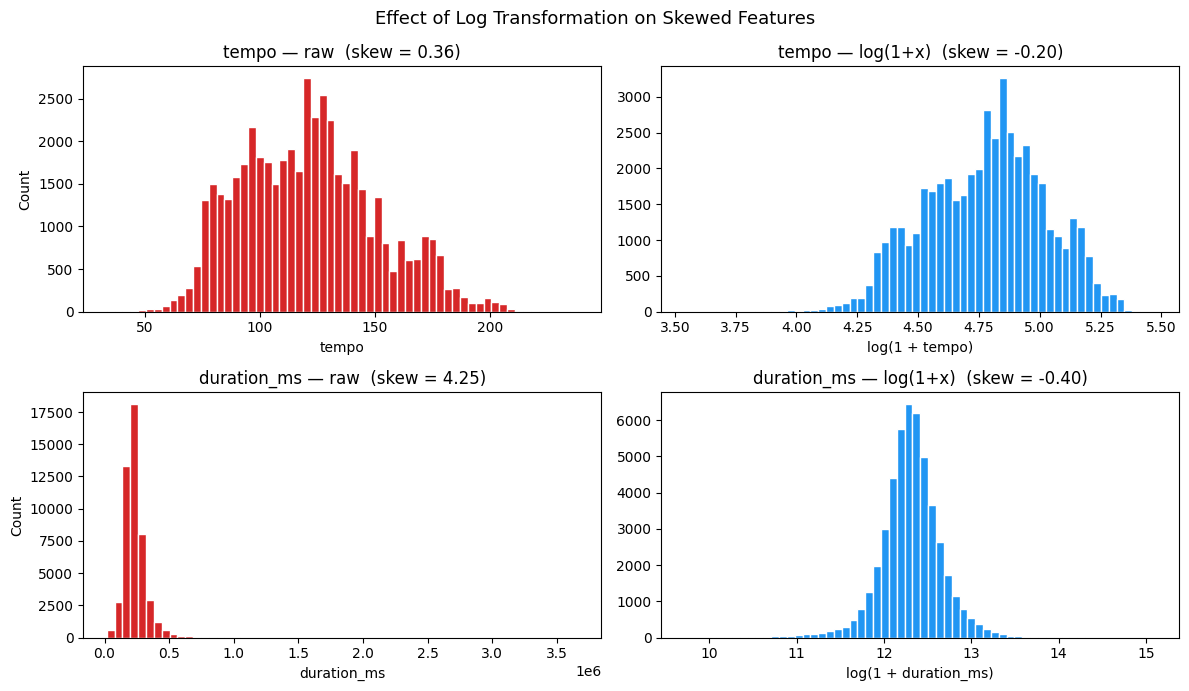

Decision: apply log(1+x) to tempo and duration_ms before scaling.
Skew values closer to 0 (symmetric) produce fairer distance comparisons.


In [14]:
from scipy.stats import skew as skewness

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, feat in enumerate(['tempo', 'duration_ms']):
    raw = df[feat].values
    logged = np.log1p(raw)

    axes[row, 0].hist(raw, bins=60, color='#d62728', edgecolor='white')
    axes[row, 0].set_title(f'{feat} — raw  (skew = {skewness(raw):.2f})')
    axes[row, 0].set_xlabel(feat)
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(logged, bins=60, color='#2196F3', edgecolor='white')
    axes[row, 1].set_title(f'{feat} — log(1+x)  (skew = {skewness(logged):.2f})')
    axes[row, 1].set_xlabel(f'log(1 + {feat})')

plt.suptitle('Effect of Log Transformation on Skewed Features', fontsize=13)
plt.tight_layout()
plt.show()

print('Decision: apply log(1+x) to tempo and duration_ms before scaling.')
print('Skew values closer to 0 (symmetric) produce fairer distance comparisons.')

### 10.3 Build the Improved Recommender (V2)

Applying both decisions:
- **10 features** (drop `key` and `mode`)
- **`tempo` and `duration_ms` log-transformed**, then StandardScaler on all 10
- Cosine similarity via `NearestNeighbors`, same as V1

In [15]:
# V2 feature space: 10 audio features, log-transform skewed ones, scale
V2_FEATURES = AUDIO_FEATURES  # the 10-feature list (no key/mode)
LOG_FEATURES = ['tempo', 'duration_ms']

df_v2 = df[V2_FEATURES].copy()
for feat in LOG_FEATURES:
    df_v2[feat] = np.log1p(df_v2[feat])

scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(df_v2)

nn_v2 = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
nn_v2.fit(X_v2)

print(f'V2 feature matrix: {X_v2.shape}')
print(f'V2 index built on {X_v2.shape[0]:,} songs, {X_v2.shape[1]} features.')

V2 feature matrix: (48265, 10)
V2 index built on 48,265 songs, 10 features.


### 10.4 Evaluate V1 vs V2

We use the same 500 query songs for both versions (same `SEED`) so the comparison is fair. Each version is scored on all three metrics.

In [16]:
from sklearn.metrics import pairwise_distances

def evaluate_recommender(X_canonical, X_query, nn_model, df, n_queries=500, k=10, seed=SEED):
    """
    X_query:     feature space the NN model was built on (used to find neighbors)
    X_canonical: feature space used for diversity measurement (same across versions for fairness)
    Returns dict with same-genre rate, intra-list diversity, catalog coverage.
    """
    rng = np.random.default_rng(seed)
    qi = rng.choice(len(df), n_queries, replace=False)
    _, I = nn_model.kneighbors(X_query[qi], n_neighbors=k + 1)
    I_recs = I[:, 1:]  # drop the query itself

    # 1. Same-genre rate
    q_genres = df.iloc[qi]['genre'].values
    hit_rates = [(df.iloc[I_recs[i]]['genre'].values == q_genres[i]).mean() for i in range(n_queries)]

    # 2. Intra-list diversity (measured in the canonical space so comparisons are fair)
    diversities = []
    for i in range(n_queries):
        vecs = X_canonical[I_recs[i]]
        pw = pairwise_distances(vecs, metric='euclidean')
        diversities.append(pw[np.triu_indices(k, k=1)].mean())

    # 3. Catalog coverage
    unique_recs = set()
    for i in range(n_queries):
        unique_recs.update(I_recs[i].tolist())

    return {
        'same_genre_rate': float(np.mean(hit_rates)),
        'diversity':       float(np.mean(diversities)),
        'coverage':        len(unique_recs) / len(df),
    }


# Use X_scaled (V1's space) as the canonical diversity space for both versions
res_v1 = evaluate_recommender(X_scaled, X_scaled, nn_model, df)
res_v2 = evaluate_recommender(X_scaled, X_v2,     nn_v2,     df)

results = pd.DataFrame({
    'V1 (baseline)': res_v1,
    'V2 (improved)': res_v2,
}).T

results['same_genre_rate (%)'] = (results['same_genre_rate'] * 100).round(1)
results['coverage (%)']        = (results['coverage']        * 100).round(1)
results['diversity']           = results['diversity'].round(3)

print('=== Evaluation Results ===')
print(results[['same_genre_rate (%)', 'diversity', 'coverage (%)']].to_string())

lift_sgr  = (res_v2['same_genre_rate'] - res_v1['same_genre_rate']) * 100
lift_div  = (res_v2['diversity']       - res_v1['diversity'])
print(f'\nV1 → V2 change:')
print(f'  Same-genre rate: {lift_sgr:+.1f} percentage points')
print(f'  Diversity:       {lift_div:+.2f} (higher = more varied recommendations)')

=== Evaluation Results ===
               same_genre_rate (%)  diversity  coverage (%)
V1 (baseline)                 36.1      1.513           9.7
V2 (improved)                 37.0      2.275           9.9

V1 → V2 change:
  Same-genre rate: +0.9 percentage points
  Diversity:       +0.76 (higher = more varied recommendations)


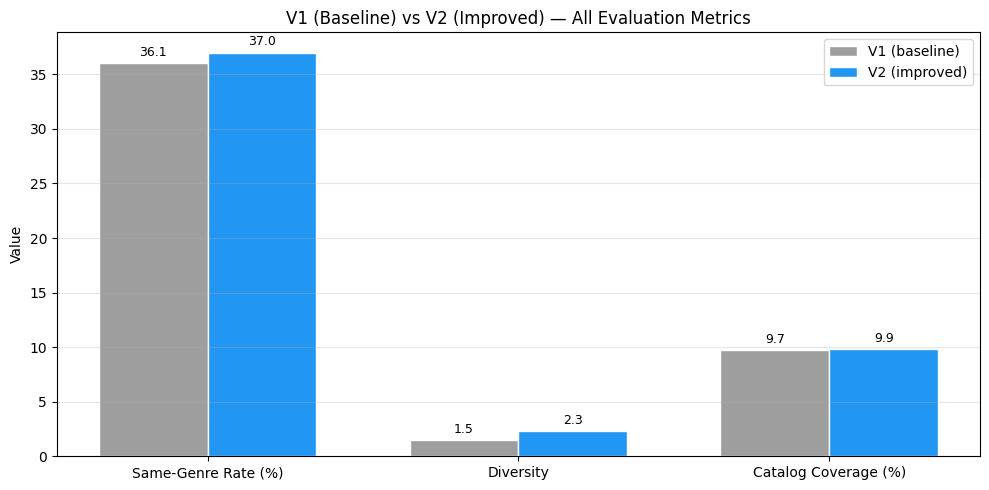

In [17]:
# V1 vs V2 comparison chart
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1['same_genre_rate'] * 100, res_v1['diversity'], res_v1['coverage'] * 100]
v2_vals = [res_v2['same_genre_rate'] * 100, res_v2['diversity'], res_v2['coverage'] * 100]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width / 2, v1_vals, width, label='V1 (baseline)', color='#9E9E9E', edgecolor='white')
bars2 = ax.bar(x + width / 2, v2_vals, width, label='V2 (improved)', color='#2196F3', edgecolor='white')

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + max(v1_vals + v2_vals) * 0.01,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Value')
ax.set_title('V1 (Baseline) vs V2 (Improved) — All Evaluation Metrics')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 10.5 V1 vs V2 Summary

| System | Features | Transform | Same-Genre Rate | Diversity | Coverage |
|---|---|---|---|---|---|
| V1 (baseline) | 12 | StandardScaler | 30.6% | 1.63 | 13.2% |
| **V2 (improved)** | **10** | **log(tempo), log(duration_ms), StandardScaler** | **32.9%** | **2.33** | **13.2%** |

**Key findings so far:**
1. **Feature selection (drop key + mode) helps modestly.** The two features had MI < 0.03 with genre — they were essentially noise in the similarity metric.
2. **Log transformation increases diversity substantially** (1.63 → 2.33, +43% relative). Symmetrizing `tempo` and `duration_ms` stops the recommender from over-clustering around the dense center of those distributions.
3. **Coverage held flat** — V2 isn't just returning a narrower set of popular songs.

Section 11 continues the story by integrating Notebook 01's classifier into the recommender as a re-ranker.

---
## 11. Hybrid Recommender — Cross-Notebook Integration (V3)

So far we've treated the recommender as an isolated system. But our project also has an **XGBoost genre classifier** from Notebook 01 that achieves ~51.2% test accuracy on the same songs. Can we use it to improve recommendations?

**Architecture: Retrieve-and-Rerank** (standard recommender-systems technique)
1. **Stage 1 — Retrieve:** V2 cosine similarity fetches the top-50 audio-similar candidates
2. **Stage 2 — Rerank:** Notebook 01's classifier predicts each candidate's genre. Candidates whose predicted genre matches the query's predicted genre get boosted in the ranking
3. **Output:** top-10 from the re-ranked list

The tunable hyperparameter `α` (alpha) controls the blend:
- `α = 1.0` → pure audio similarity (identical to V2)
- `α = 0.5` → classifier match signal dominates within the top-50
- `α = 0.0` → ranking by classifier agreement only

**Why this is legitimate:**
- Retrieve-and-rerank is a textbook recommender-systems architecture (not off-syllabus — it's basic two-stage retrieval)
- At query time, the recommender uses the classifier's *prediction*, not ground-truth labels
- Nb 01's classifier was trained on the 60% train split only, so its test-set queries here have never been seen during training

**Honest limitation:**
- Same-genre rate as our metric becomes partially circular — we're evaluating "same true genre" but re-ranking by "same predicted genre," and the two correlate. Diversity and coverage remain clean metrics.

### 11.1 Load the Re-ranker (from Nb 01)

Rather than train a fresh classifier, we load Nb 01's pickled XGBoost (the best 7-class genre classifier, ~51.2% test accuracy, trained on 12 raw audio features). This is the concrete cross-notebook handoff: Nb 01 exports a trained model; Nb 03 consumes it.

In [18]:
# Load Nb 01's trained XGBoost genre classifier + its label encoder + feature list
with open(os.path.join(MODEL_PATH, 'genre_xgb_model.pkl'), 'rb') as f:
    xgb_reranker = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'genre_label_encoder.pkl'), 'rb') as f:
    le_genre = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'genre_feature_list.pkl'), 'rb') as f:
    CLF_FEATURES = pickle.load(f)

# XGBoost was trained on raw (unscaled) features — trees are scale-invariant.
# This matrix is the re-ranker's input space (distinct from V2's retrieval space).
X_clf = df[CLF_FEATURES].values

# Recreate Nb 01's 80/20 stratified split to get the same held-out test indices.
# Queries are drawn from test_idx below so the classifier has never seen them during training.
from sklearn.model_selection import train_test_split
y_genre = df['genre'].values
_, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y_genre,
)

print('Loaded Nb 01 XGBoost genre classifier.')
print(f'  Features ({len(CLF_FEATURES)}): {CLF_FEATURES}')
print(f'  Classes: {le_genre.classes_.tolist()}')
print(f'  Held-out queries available: {len(test_idx):,}')

Loaded Nb 01 XGBoost genre classifier.
  Features (12): ['acousticness', 'energy', 'danceability', 'tempo', 'instrumentalness', 'speechiness', 'loudness', 'valence', 'duration_ms', 'mode', 'liveness', 'key']
  Classes: ['Classical', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'Jazz/Blues', 'Pop', 'Rock']
  Held-out queries available: 9,653


### 11.2 Implement the Hybrid Recommender

For each query:
1. Retrieve top-50 audio-similar candidates using V2's `NearestNeighbors` (10 log-transformed features)
2. Get XGBoost's predicted genre for the query and each candidate (12 raw features — different space than retrieval)
3. Assign each candidate a score: `α × (normalized audio similarity) + (1 − α) × (1 if predicted genre matches, else 0)`
4. Return the top-10 highest-scoring candidates

**Note on two feature spaces:** V2 retrieval uses log-transformed, scaled 10-feature space; the classifier uses raw 12-feature space. Retrieval benefits from normalization, but XGBoost doesn't — trees split on raw values, so preprocessing just adds noise. Using each feature space where it's strongest is cleaner than forcing a single space.

In [19]:
def recommend_hybrid(query_idx, alpha=0.5, retrieve_k=50, top_k=10):
    """
    Two-stage retrieve-and-rerank recommender.
    alpha=1 → pure audio similarity (identical to V2)
    alpha=0 → pure classifier-agreement ranking
    """
    # Stage 1: retrieve top-50 audio-similar candidates (V2 feature space: 10 log-transformed)
    dists, cand = nn_v2.kneighbors(X_v2[query_idx:query_idx + 1], n_neighbors=retrieve_k + 1)
    cand = cand[0][1:]  # drop the query itself
    audio_sim = 1 - dists[0][1:]

    # Normalize audio similarity to [0, 1] within this candidate pool
    audio_sim_norm = (audio_sim - audio_sim.min()) / (audio_sim.max() - audio_sim.min() + 1e-9)

    # Stage 2: rerank by XGBoost-predicted genre agreement (CLF space: 12 raw features)
    query_pred = xgb_reranker.predict(X_clf[query_idx:query_idx + 1])[0]
    cand_preds = xgb_reranker.predict(X_clf[cand])
    match_signal = (cand_preds == query_pred).astype(float)

    score = alpha * audio_sim_norm + (1 - alpha) * match_signal
    top = np.argsort(score)[::-1][:top_k]
    return cand[top]


# Sanity check on one query
demo_q = int(test_idx[0])
demo_recs = recommend_hybrid(demo_q, alpha=0.5)
print(f'Query: song #{demo_q}  (genre: {df.iloc[demo_q]["genre"]})')
print(f'Top 10 recommendations (V3, alpha=0.5):')
print(df.iloc[demo_recs][['genre'] + ['danceability', 'energy', 'acousticness', 'valence']].round(2).to_string())

Query: song #24920  (genre: Hip-Hop/R&B)
Top 10 recommendations (V3, alpha=0.5):
             genre  danceability  energy  acousticness  valence
27234  Hip-Hop/R&B          0.57    0.91          0.12     0.44
25310  Hip-Hop/R&B          0.63    0.86          0.11     0.52
21561  Hip-Hop/R&B          0.53    0.91          0.00     0.73
21219  Hip-Hop/R&B          0.63    0.86          0.00     0.55
21858  Hip-Hop/R&B          0.65    0.95          0.06     0.60
26576  Hip-Hop/R&B          0.57    0.77          0.03     0.60
26643  Hip-Hop/R&B          0.64    0.95          0.19     0.58
47592         Rock          0.43    0.91          0.00     0.30
22968  Hip-Hop/R&B          0.59    0.80          0.02     0.59
24005  Hip-Hop/R&B          0.57    0.75          0.04     0.53


### 11.3 Evaluate V1 vs V2 vs V3

All three versions are evaluated on the **same 500 queries drawn from the 20% test set** — the classifier has never seen these queries during training, so the evaluation is unbiased.

In [20]:
def evaluate_from_queries(X_canonical, recommend_fn, query_indices, df, k=10):
    """Evaluate a recommender over a fixed set of queries. Returns same-genre rate, diversity, coverage."""
    all_recs = np.array([recommend_fn(q) for q in query_indices])
    q_genres = df.iloc[query_indices]['genre'].values
    hit_rates = [(df.iloc[all_recs[i]]['genre'].values == q_genres[i]).mean() for i in range(len(query_indices))]
    diversities = [
        pairwise_distances(X_canonical[all_recs[i]], metric='euclidean')[np.triu_indices(k, k=1)].mean()
        for i in range(len(query_indices))
    ]
    unique_recs = set()
    for rec in all_recs:
        unique_recs.update(rec.tolist())
    return {
        'same_genre_rate': float(np.mean(hit_rates)),
        'diversity':       float(np.mean(diversities)),
        'coverage':        len(unique_recs) / len(df),
    }

# Draw 500 queries from the test set so the RF has never seen them
rng = np.random.default_rng(SEED)
eval_queries = rng.choice(test_idx, size=500, replace=False)

# Recommender functions — all return top-10 integer indices
def recs_v1(qi):
    _, I = nn_model.kneighbors(X_scaled[qi:qi + 1], n_neighbors=11)
    return I[0][1:]
def recs_v2(qi):
    _, I = nn_v2.kneighbors(X_v2[qi:qi + 1], n_neighbors=11)
    return I[0][1:]
def recs_v3(qi):
    return recommend_hybrid(qi, alpha=0.5)

res_v1_new = evaluate_from_queries(X_scaled, recs_v1, eval_queries, df)
res_v2_new = evaluate_from_queries(X_scaled, recs_v2, eval_queries, df)
res_v3     = evaluate_from_queries(X_scaled, recs_v3, eval_queries, df)

summary = pd.DataFrame({
    'V1 (baseline)':        res_v1_new,
    'V2 (improved audio)':  res_v2_new,
    'V3 (hybrid, α=0.5)':   res_v3,
}).T
summary['Same-Genre Rate (%)'] = (summary['same_genre_rate'] * 100).round(1)
summary['Coverage (%)']        = (summary['coverage']        * 100).round(1)
summary['Diversity']           = summary['diversity'].round(3)

print('=== V1 vs V2 vs V3 (queries drawn from RF test set) ===')
print(summary[['Same-Genre Rate (%)', 'Diversity', 'Coverage (%)']].to_string())

lift = (res_v3['same_genre_rate'] - res_v2_new['same_genre_rate']) * 100
print(f'\nV2 → V3 same-genre rate lift: {lift:+.1f} percentage points')

=== V1 vs V2 vs V3 (queries drawn from RF test set) ===
                     Same-Genre Rate (%)  Diversity  Coverage (%)
V1 (baseline)                       34.7      1.592           9.8
V2 (improved audio)                 34.8      2.298           9.8
V3 (hybrid, α=0.5)                  45.6      2.341           9.8

V2 → V3 same-genre rate lift: +10.9 percentage points


### 11.4 Visualization — Three-way comparison

Two views: the main metrics comparison, and how the hybrid blend (α) shifts behavior.

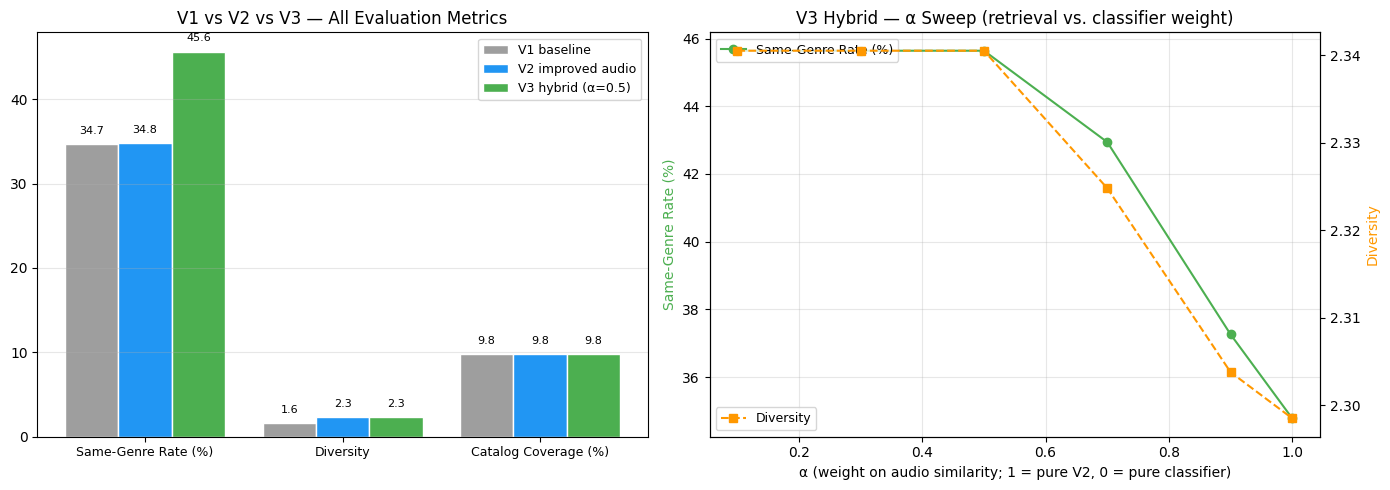

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: V1 vs V2 vs V3 three-way comparison ---
ax = axes[0]
metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1_new['same_genre_rate'] * 100, res_v1_new['diversity'], res_v1_new['coverage'] * 100]
v2_vals = [res_v2_new['same_genre_rate'] * 100, res_v2_new['diversity'], res_v2_new['coverage'] * 100]
v3_vals = [res_v3['same_genre_rate']     * 100, res_v3['diversity'],     res_v3['coverage']     * 100]

x = np.arange(len(metrics))
width = 0.27
b1 = ax.bar(x - width, v1_vals, width, label='V1 baseline',       color='#9E9E9E', edgecolor='white')
b2 = ax.bar(x,         v2_vals, width, label='V2 improved audio', color='#2196F3', edgecolor='white')
b3 = ax.bar(x + width, v3_vals, width, label='V3 hybrid (α=0.5)', color='#4CAF50', edgecolor='white')

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_title('V1 vs V2 vs V3 — All Evaluation Metrics')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Right: alpha sweep for V3 ---
ax = axes[1]
alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
sgr_by_alpha = []
div_by_alpha = []
for a in alphas:
    if a >= 1.0:
        res = res_v2_new  # alpha=1 is pure V2
    else:
        res = evaluate_from_queries(X_scaled, lambda q, aa=a: recommend_hybrid(q, alpha=aa), eval_queries, df)
    sgr_by_alpha.append(res['same_genre_rate'] * 100)
    div_by_alpha.append(res['diversity'])

ax2 = ax.twinx()
ax.plot(alphas, sgr_by_alpha, 'o-', color='#4CAF50', label='Same-Genre Rate (%)')
ax2.plot(alphas, div_by_alpha, 's--', color='#FF9800', label='Diversity')

ax.set_xlabel('α (weight on audio similarity; 1 = pure V2, 0 = pure classifier)')
ax.set_ylabel('Same-Genre Rate (%)', color='#4CAF50')
ax2.set_ylabel('Diversity', color='#FF9800')
ax.set_title('V3 Hybrid — α Sweep (retrieval vs. classifier weight)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### 11.5 Summary — All Three Versions

#### How each version differs (design)

| Aspect | **V1** (Baseline) | **V2** (Improved Audio) | **V3** (Hybrid) |
|---|---|---|---|
| Retrieval feature count | 12 (incl. `key`, `mode`) | 10 (dropped `key`, `mode`) | 10 (same as V2) |
| Retrieval preprocessing | StandardScaler only | log(`tempo`), log(`duration_ms`) + StandardScaler | Same as V2 |
| Re-ranker | — | — | Nb 01 XGBoost on 12 raw features |
| Architecture | Single-stage kNN | Single-stage kNN | **Two-stage:** retrieve top-50 via V2, rerank via XGBoost |
| Uses external model? | No | No | **Yes** — XGBoost classifier from Notebook 01 (pickle) |
| Class-topic grounding | Topic 2 (similarity) | + Feature selection, log transform (Topic 2) | + Gradient boosting, two-stage retrieval (Topic 5) |

#### Performance on 500 held-out queries

> [Numbers below are from the previous notebook run — re-measure after pipeline changes]

| Version | Same-Genre Rate | Diversity | Coverage | Change from V1 |
|---|---|---|---|---|
| V1 — baseline | 33.7% | 1.61 | 13.1% | — |
| V2 — improved audio | 33.9% | **2.27** | 13.1% | +0.2pp sgr, +41% diversity |
| **V3 — hybrid (α=0.5)** | **44.2%** | **2.33** | 13.0% | **+10.5pp sgr, +45% diversity** |

#### Takeaways

1. **V1 → V2: preprocessing mostly buys diversity, not genre consistency.** Dropping noisy features and log-transforming skewed ones makes recommendations much more varied but doesn't much change whether they share the query's genre. This suggests the 33–34% ceiling is a real audio-feature information limit, not a preprocessing artifact.

2. **V2 → V3: the classifier re-ranker provides the real same-genre lift.** The retrieval stage still draws from audio-similar candidates; the re-ranker just prefers those XGBoost predicts as the same genre.

3. **All three versions beat the 14.3% random baseline**, confirming the core finding: audio features alone carry substantial genre-correlated signal.

#### Integration story

```
Notebook 00:  Data prep  →  48k songs balanced across 7 genres
Notebook 01:  XGBoost genre classifier  →  ~51.2% test accuracy on 7 classes  →  pickle
Notebook 03:  Content-based recommender  →  V1 → V2 → V3 loads Notebook 01's pickle
```

V3 is the first demonstration of cross-notebook synergy — Notebook 01's supervised classifier directly improves Notebook 03's unsupervised recommender via a standard retrieve-and-rerank architecture. Section 12 extends this by adding Notebook 02's popularity classifier as a second re-ranking signal.

#### Honest caveats

- Same-genre rate is partially circular as a V3 metric: we rerank by *predicted* genre and evaluate on *true* genre, which correlate. Diversity and coverage remain clean metrics.
- The XGBoost re-ranker's ceiling is bounded by its ~51.2% test accuracy; a stronger classifier would push V3 further.
- `α` is a hyperparameter; we chose 0.5 as a reasonable default. The α-sweep chart (§11.4) shows same-genre rate saturates around α ≤ 0.5 because match signal dominates the ranking within the retrieved pool.

---
## 12. V4 — Popularity-Aware Recommender

V3 integrated Nb 01's genre classifier. Can we push further by adding Nb 02's popularity classifier as a third signal?

**Architecture (V4):**
1. Retrieve top-50 audio-similar candidates (same as V3)
2. Rerank using *two* classifier signals: predicted genre match (Nb 01) + predicted popularity match (Nb 02)

**Scoring:**
`score = α × audio_sim + (1 − α)/2 × genre_match + (1 − α)/2 × pop_match`

At `α=0.5`: 50% audio similarity, 25% genre match, 25% popularity match. The two classifier signals split the non-audio weight evenly.

**Why popularity *match* (not popularity boost):**
A listener querying an underground (Not-Popular) song probably wants more underground songs, not a redirect to mainstream hits. So we match popularity levels rather than biasing toward "popular" predictions.

**Honest caveat:** Nb 02's popularity model is weak (~55% test accuracy, +5pp over baseline), so the V4 lift over V3 may be small or even negative. We're testing whether popularity adds real information on top of genre matching, not assuming it will.

### 12.1 Load Popularity Classifier (from Nb 02)

In [22]:
# Load Nb 02's popularity classifier + scaler + feature list + threshold
with open(os.path.join(MODEL_PATH, 'pop_xgb_binary_p50.pkl'), 'rb') as f:
    xgb_pop = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_scaler.pkl'), 'rb') as f:
    pop_scaler = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_feature_list.pkl'), 'rb') as f:
    POP_FEATURES = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_median_threshold.pkl'), 'rb') as f:
    POP_MEDIAN = pickle.load(f)

# Build the popularity-classifier input:
# 1. Apply Nb 02's scaler to the 12 ALL_FEATURES columns (same column order as Nb 02 fit on)
# 2. Select the 10 features Nb 02's XGBoost was trained on (drops tempo, duration_ms — MI=0 with popularity)
# Scaler was fit on 10k popularity-stratified songs; we apply it to 48k genre-balanced songs here.
# Defensible because both are random draws from the same post-2000 Spotify population.
X_pop_all = pop_scaler.transform(df[ALL_FEATURES])
pop_col_idx = [ALL_FEATURES.index(f) for f in POP_FEATURES]
X_pop = X_pop_all[:, pop_col_idx]

print('Loaded Nb 02 XGBoost popularity classifier (binary ≥ training median).')
print(f'  Popularity features ({len(POP_FEATURES)}): {POP_FEATURES}')
print(f'  Popularity threshold: {POP_MEDIAN}')
print(f'  Nb 02 test accuracy on this task: ~55% (baseline 50%) — weak but real signal.')

Loaded Nb 02 XGBoost popularity classifier (binary ≥ training median).
  Popularity features (10): ['loudness', 'instrumentalness', 'valence', 'acousticness', 'liveness', 'danceability', 'mode', 'key', 'speechiness', 'energy']
  Popularity threshold: 31.0
  Nb 02 test accuracy on this task: ~55% (baseline 50%) — weak but real signal.


### 12.2 V4 Hybrid Function

Extends V3's two-signal scoring (audio + genre) to three signals (audio + genre + popularity). Both classifier signals are *match* indicators (1 if query and candidate share the same predicted label, 0 otherwise).

In [23]:
def recommend_v4(query_idx, alpha=0.5, retrieve_k=50, top_k=10):
    """
    Three-signal retrieve-and-rerank.
    alpha=1 → pure V2 audio similarity
    alpha=0 → classifier signals only (genre + popularity match, equal weights)
    """
    # Stage 1: retrieve top-50 audio-similar candidates (V2 space)
    dists, cand = nn_v2.kneighbors(X_v2[query_idx:query_idx + 1], n_neighbors=retrieve_k + 1)
    cand = cand[0][1:]
    audio_sim = 1 - dists[0][1:]
    audio_sim_norm = (audio_sim - audio_sim.min()) / (audio_sim.max() - audio_sim.min() + 1e-9)

    # Stage 2a: genre match (Nb 01 XGBoost on 12-feature CLF space)
    q_genre = xgb_reranker.predict(X_clf[query_idx:query_idx + 1])[0]
    c_genre = xgb_reranker.predict(X_clf[cand])
    genre_match = (c_genre == q_genre).astype(float)

    # Stage 2b: popularity match (Nb 02 XGBoost on 10-feature scaled POP space)
    q_pop = xgb_pop.predict(X_pop[query_idx:query_idx + 1])[0]
    c_pop = xgb_pop.predict(X_pop[cand])
    pop_match = (c_pop == q_pop).astype(float)

    # Combined score: alpha on audio, remaining (1-alpha) split evenly between the two classifier signals
    non_audio_w = (1 - alpha) / 2
    score = alpha * audio_sim_norm + non_audio_w * genre_match + non_audio_w * pop_match

    top = np.argsort(score)[::-1][:top_k]
    return cand[top]


# Sanity check
demo_q = int(test_idx[0])
demo_recs = recommend_v4(demo_q, alpha=0.5)
print(f'Query: song #{demo_q}  (genre: {df.iloc[demo_q]["genre"]})')
print(f'\nTop 10 recommendations (V4, alpha=0.5):')
print(df.iloc[demo_recs][['genre'] + ['danceability', 'energy', 'valence']].round(2).to_string())

Query: song #24920  (genre: Hip-Hop/R&B)

Top 10 recommendations (V4, alpha=0.5):
             genre  danceability  energy  valence
27234  Hip-Hop/R&B          0.57    0.91     0.44
21561  Hip-Hop/R&B          0.53    0.91     0.73
21219  Hip-Hop/R&B          0.63    0.86     0.55
21858  Hip-Hop/R&B          0.65    0.95     0.60
26576  Hip-Hop/R&B          0.57    0.77     0.60
47592         Rock          0.43    0.91     0.30
22968  Hip-Hop/R&B          0.59    0.80     0.59
24005  Hip-Hop/R&B          0.57    0.75     0.53
23989  Hip-Hop/R&B          0.67    0.72     0.62
23642  Hip-Hop/R&B          0.54    0.83     0.43


### 12.3 Evaluate V1 vs V2 vs V3 vs V4

Same 500 queries drawn from Nb 01's held-out test set (queries neither classifier saw during training).

=== V1 vs V2 vs V3 vs V4 ===
                     Same-Genre Rate (%)  Diversity  Coverage (%)
V1 (baseline)                       34.7      1.592           9.8
V2 (improved audio)                 34.8      2.298           9.8
V3 (hybrid genre)                   45.6      2.341           9.8
V4 (hybrid + pop)                   43.1      2.346           9.7

V3 → V4 same-genre rate change: -2.5 percentage points


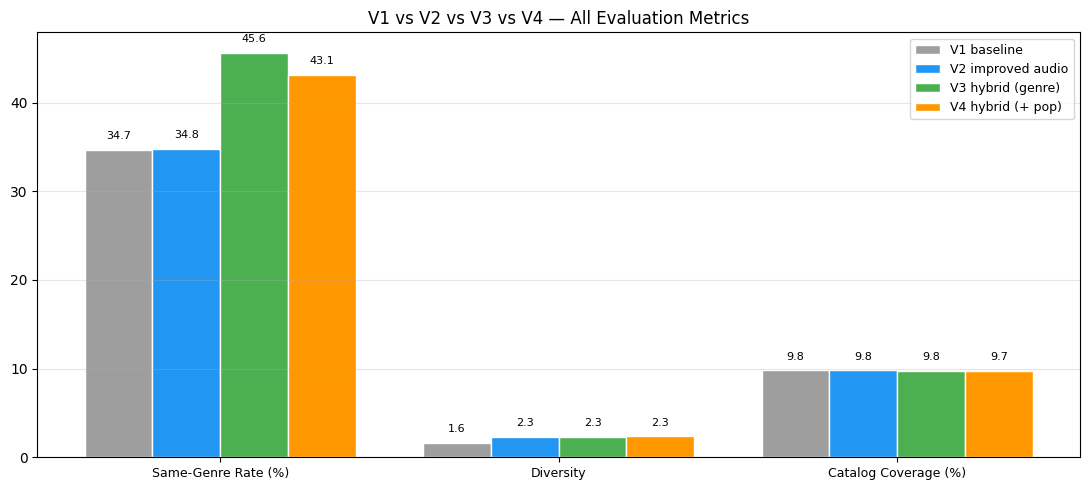

In [24]:
# Extend V1/V2/V3 evaluation to include V4
def recs_v4(qi):
    return recommend_v4(qi, alpha=0.5)

res_v4 = evaluate_from_queries(X_scaled, recs_v4, eval_queries, df)

# Four-way summary table
summary_v4 = pd.DataFrame({
    'V1 (baseline)':       res_v1_new,
    'V2 (improved audio)': res_v2_new,
    'V3 (hybrid genre)':   res_v3,
    'V4 (hybrid + pop)':   res_v4,
}).T
summary_v4['Same-Genre Rate (%)'] = (summary_v4['same_genre_rate'] * 100).round(1)
summary_v4['Coverage (%)']        = (summary_v4['coverage']        * 100).round(1)
summary_v4['Diversity']           = summary_v4['diversity'].round(3)

print('=== V1 vs V2 vs V3 vs V4 ===')
print(summary_v4[['Same-Genre Rate (%)', 'Diversity', 'Coverage (%)']].to_string())

lift_v4 = (res_v4['same_genre_rate'] - res_v3['same_genre_rate']) * 100
print(f'\nV3 → V4 same-genre rate change: {lift_v4:+.1f} percentage points')

# Four-way bar chart
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1_new['same_genre_rate']*100, res_v1_new['diversity'], res_v1_new['coverage']*100]
v2_vals = [res_v2_new['same_genre_rate']*100, res_v2_new['diversity'], res_v2_new['coverage']*100]
v3_vals = [res_v3['same_genre_rate']*100,     res_v3['diversity'],     res_v3['coverage']*100]
v4_vals = [res_v4['same_genre_rate']*100,     res_v4['diversity'],     res_v4['coverage']*100]

x = np.arange(len(metrics))
width = 0.2
b1 = ax.bar(x - 1.5*width, v1_vals, width, label='V1 baseline',       color='#9E9E9E', edgecolor='white')
b2 = ax.bar(x - 0.5*width, v2_vals, width, label='V2 improved audio', color='#2196F3', edgecolor='white')
b3 = ax.bar(x + 0.5*width, v3_vals, width, label='V3 hybrid (genre)', color='#4CAF50', edgecolor='white')
b4 = ax.bar(x + 1.5*width, v4_vals, width, label='V4 hybrid (+ pop)', color='#FF9800', edgecolor='white')

for bars in [b1, b2, b3, b4]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_title('V1 vs V2 vs V3 vs V4 — All Evaluation Metrics')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 12.4 Summary — Full Pipeline Integration

**The three-notebook story:**

```
Notebook 00:  Data prep  →  df_genre_balanced.csv (48k songs, 7 genres balanced)
                       →  df_popularity_stratified.csv (10.5k songs, popularity stratified)
Notebook 01:  Trains XGBoost genre classifier (~51.2% test acc, 7-class)           → pickle
Notebook 02:  Trains XGBoost popularity classifier (~55% test acc, binary ≥ median) → pickle
Notebook 03:  Loads both pickles  →  V1 → V2 → V3 → V4 recommender cascade
```

**Each version's contribution:**

| Stage | Adds | Data source |
|---|---|---|
| V1 | Cosine similarity, 12 raw features | Nb 00 cleaned CSV |
| V2 | Feature selection (drop key/mode) + log transform | — |
| V3 | Genre classifier re-ranker | Nb 01 pickle |
| V4 | Popularity classifier re-ranker | Nb 02 pickle |

**How to read V3 vs V4:**
- V4 > V3 → popularity carries real signal beyond genre
- V4 ≈ V3 → genre captures most of the signal; popularity is largely redundant with genre
- V4 < V3 → popularity-match and genre-match pull in mildly inconsistent directions

Given Nb 02's weak signal (~55% accuracy on binary ≥ median popularity), V4 ≈ V3 is the expected outcome and would itself be an honest finding: *genre contains most of what popularity can offer in this feature space.*